In [12]:
import numpy as a
import pandas as b
import matplotlib.pyplot as c

print(a.__version__)
print(b.__version__)

1.26.4
2.2.3


In [13]:
def col_stats(a_arr):
    d = a.mean(a_arr, axis=0)
    e = a.std(a_arr, axis=0)
    f = a.min(a_arr, axis=0)
    g = a.max(a_arr, axis=0)
    return d, e, f, g

def pair_dist(a_arr, b_arr):
    d = a_arr[:, a.newaxis, :]
    e = b_arr[a.newaxis, :, :]
    return a.sqrt(a.sum((d - e) ** 2, axis=-1))

def conf_mat_multi(a_true, b_pred):
    a_true = a.asarray(a_true)
    b_pred = a.asarray(b_pred)
    d = a.unique(a.concatenate((a_true, b_pred)))
    e = len(d)
    f = a.zeros((e, e), dtype=int)
    for g, h in enumerate(d):
        for i, j in enumerate(d):
            f[g, i] = a.sum((a_true == h) & (b_pred == j))
    return f, d

def bin_metrics(a_true, b_pred):
    a_true = a.asarray(a_true)
    b_pred = a.asarray(b_pred)
    d = a.sum((a_true == 1) & (b_pred == 1))
    e = a.sum((a_true == 0) & (b_pred == 1))
    f = a.sum((a_true == 1) & (b_pred == 0))
    g = d / (d + e) if (d + e) > 0 else 0.0
    h = d / (d + f) if (d + f) > 0 else 0.0
    i = (2 * g * h) / (g + h) if (g + h) > 0 else 0.0
    return g, h, i

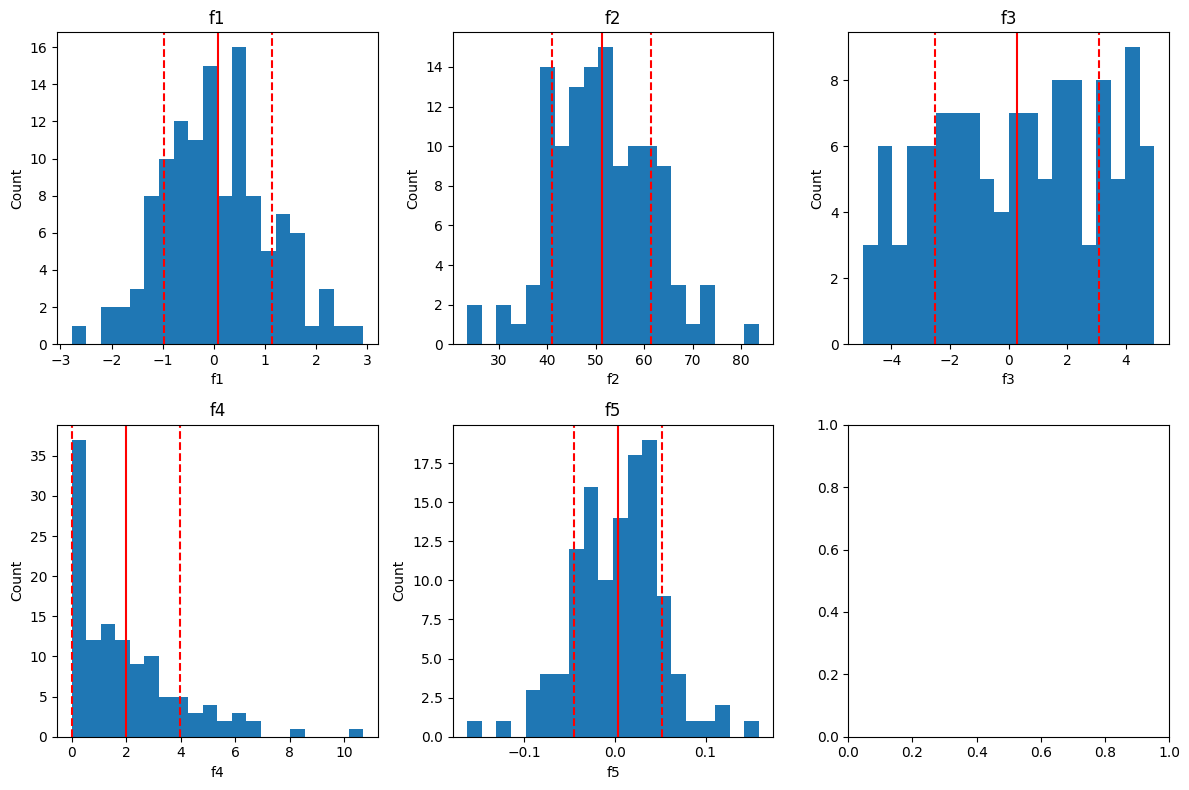

In [14]:
d = b.read_csv("lab1_features.csv")
e, f = c.subplots(2, 3, figsize=(12, 8))
g = f.flatten()
for h, i in enumerate(d.columns):
    j = d[i].values
    k, l, m, n = col_stats(j)
    g[h].hist(j, bins=20)
    g[h].axvline(k, color="red")
    g[h].axvline(k - l, color="red", linestyle="--")
    g[h].axvline(k + l, color="red", linestyle="--")
    g[h].set_xlabel(str(i))
    g[h].set_ylabel("Count")
    g[h].set_title(str(i))
c.tight_layout()
c.show()

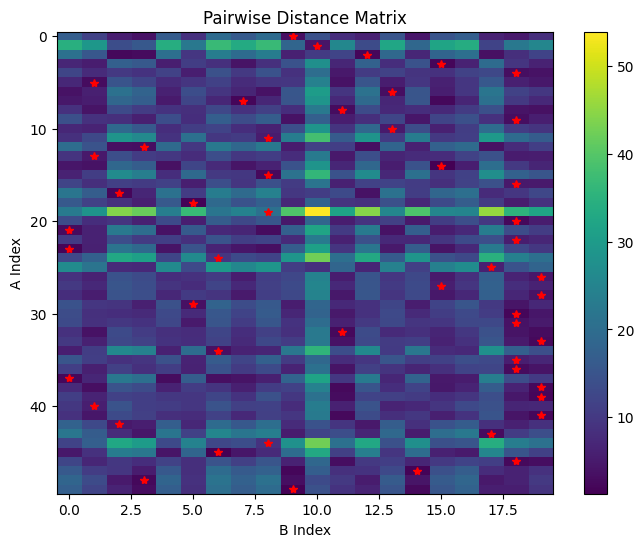

In [15]:
o = d.values
p = o[:50]
q = o[50:70]
r = pair_dist(p, q)
s, t = c.subplots(figsize=(8, 6))
u = t.imshow(r, aspect="auto")
s.colorbar(u)
v = a.argmin(r, axis=1)
for w, x in enumerate(v):
    t.plot(x, w, "r*")
t.set_xlabel("B Index")
t.set_ylabel("A Index")
t.set_title("Pairwise Distance Matrix")
c.show()

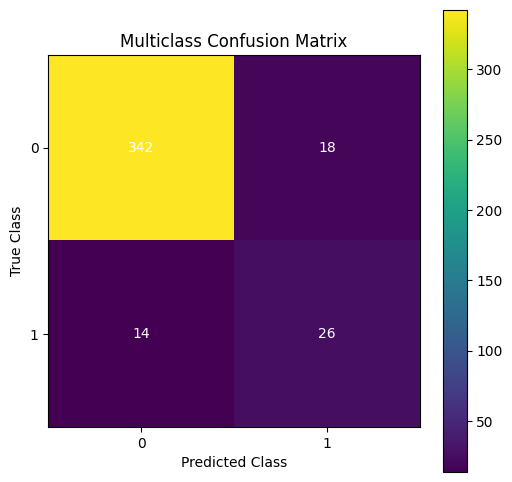

In [16]:
y = b.read_csv("lab1_predictions.csv")
z = y.iloc[:, 0].values
aa = y.iloc[:, 1].values
ab, ac = conf_mat_multi(z, aa)
ad, ae = c.subplots(figsize=(6, 6))
af = ae.imshow(ab)
ad.colorbar(af)
for ag in range(len(ac)):
    for ah in range(len(ac)):
        ae.text(ah, ag, str(ab[ag, ah]), ha="center", va="center", color="white")
ae.set_xticks(range(len(ac)))
ae.set_yticks(range(len(ac)))
ae.set_xticklabels(ac)
ae.set_yticklabels(ac)
ae.set_xlabel("Predicted Class")
ae.set_ylabel("True Class")
ae.set_title("Multiclass Confusion Matrix")
c.show()

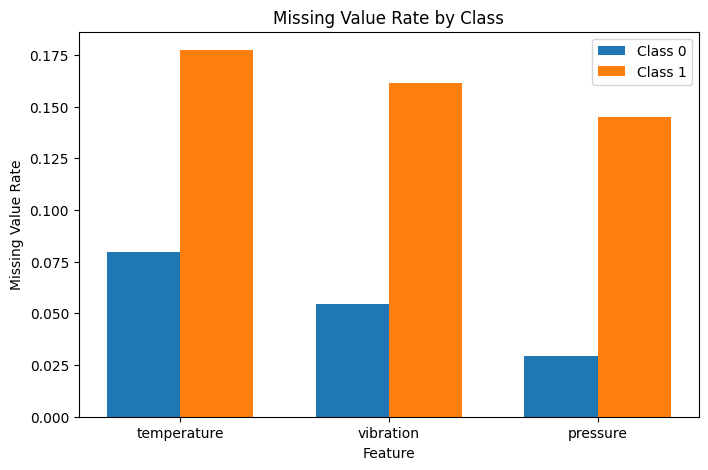

In [17]:
ai = b.read_csv("lab2_machines.csv")
aj = ["temperature", "vibration", "pressure"]
ak = ai.groupby("needs_service")[aj].apply(lambda x: x.isna().mean())
al = a.arange(len(aj))
am = 0.35
an, ao = c.subplots(figsize=(8, 5))
ao.bar(al - am/2, ak.loc[0], am, label="Class 0")
ao.bar(al + am/2, ak.loc[1], am, label="Class 1")
ao.set_xticks(al)
ao.set_xticklabels(aj)
ao.set_xlabel("Feature")
ao.set_ylabel("Missing Value Rate")
ao.set_title("Missing Value Rate by Class")
ao.legend()
c.show()

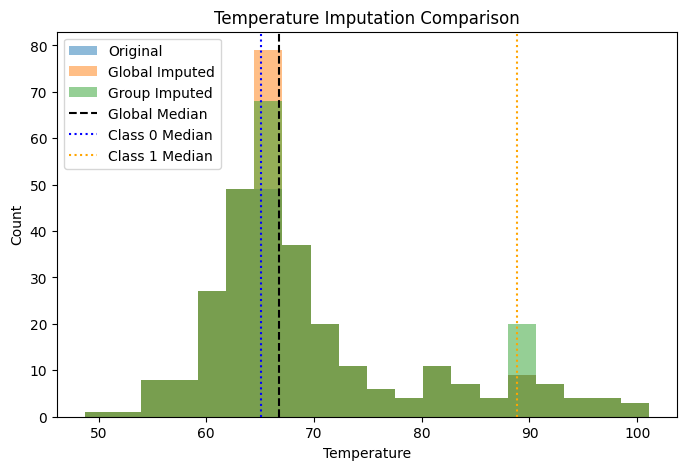

In [18]:
ap = ai["temperature"].dropna()
aq = ai["temperature"].median()
ar = ai["temperature"].fillna(aq)
as_val = ai.groupby("needs_service")["temperature"].transform("median")
at = ai["temperature"].fillna(as_val)
au, av = c.subplots(figsize=(8, 5))
av.hist(ap, bins=20, alpha=0.5, label="Original")
av.hist(ar, bins=20, alpha=0.5, label="Global Imputed")
av.hist(at, bins=20, alpha=0.5, label="Group Imputed")
av.axvline(aq, color="black", linestyle="--", label="Global Median")
aw = ai.groupby("needs_service")["temperature"].median()
av.axvline(aw[0], color="blue", linestyle=":", label="Class 0 Median")
av.axvline(aw[1], color="orange", linestyle=":", label="Class 1 Median")
av.set_xlabel("Temperature")
av.set_ylabel("Count")
av.set_title("Temperature Imputation Comparison")
av.legend()
c.show()

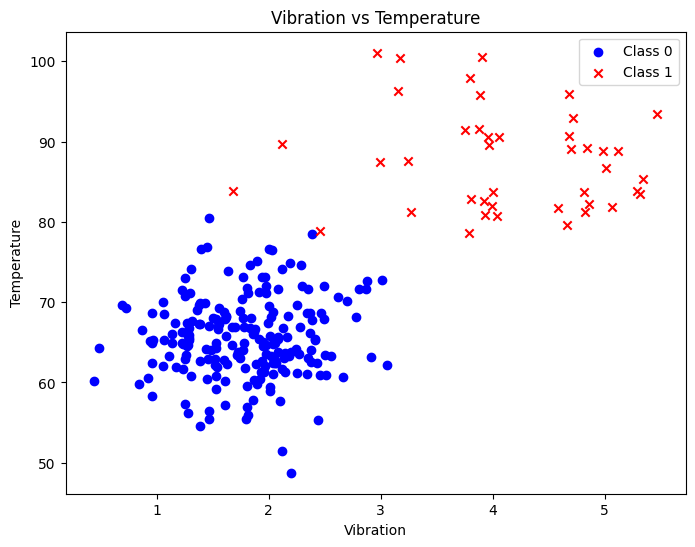

In [19]:
ax_fig, ay = c.subplots(figsize=(8, 6))
az = ai[ai["needs_service"] == 0]
ba = ai[ai["needs_service"] == 1]
ay.scatter(az["vibration"], az["temperature"], c="blue", marker="o", label="Class 0")
ay.scatter(ba["vibration"], ba["temperature"], c="red", marker="x", label="Class 1")
ay.set_xlabel("Vibration")
ay.set_ylabel("Temperature")
ay.set_title("Vibration vs Temperature")
ay.legend()
c.show()

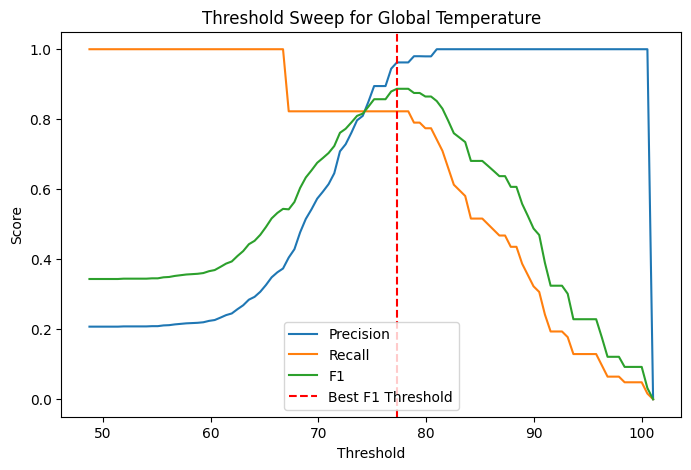

In [20]:
bb = a.linspace(ar.min(), ar.max(), 100)
bc = ai["needs_service"].values
bd, be, bf = [], [], []
for bg in bb:
    bh = (ar.values > bg).astype(int)
    bi, bj, bk = bin_metrics(bc, bh)
    bd.append(bi)
    be.append(bj)
    bf.append(bk)
bl = bb[a.argmax(bf)]
bm, bn = c.subplots(figsize=(8, 5))
bn.plot(bb, bd, label="Precision")
bn.plot(bb, be, label="Recall")
bn.plot(bb, bf, label="F1")
bn.axvline(bl, color="red", linestyle="--", label="Best F1 Threshold")
bn.set_xlabel("Threshold")
bn.set_ylabel("Score")
bn.set_title("Threshold Sweep for Global Temperature")
bn.legend()
c.show()

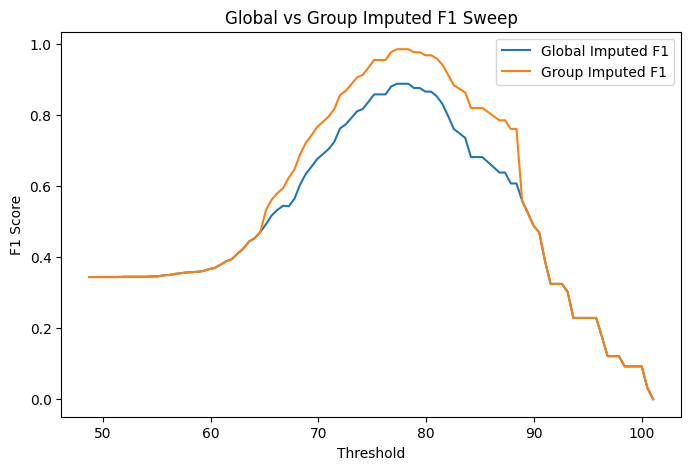

In [21]:
bo = []
for bg in bb:
    bh = (at.values > bg).astype(int)
    _, _, bk = bin_metrics(bc, bh)
    bo.append(bk)
bp, bq = c.subplots(figsize=(8, 5))
bq.plot(bb, bf, label="Global Imputed F1")
bq.plot(bb, bo, label="Group Imputed F1")
bq.set_xlabel("Threshold")
bq.set_ylabel("F1 Score")
bq.set_title("Global vs Group Imputed F1 Sweep")
bq.legend()
c.show()

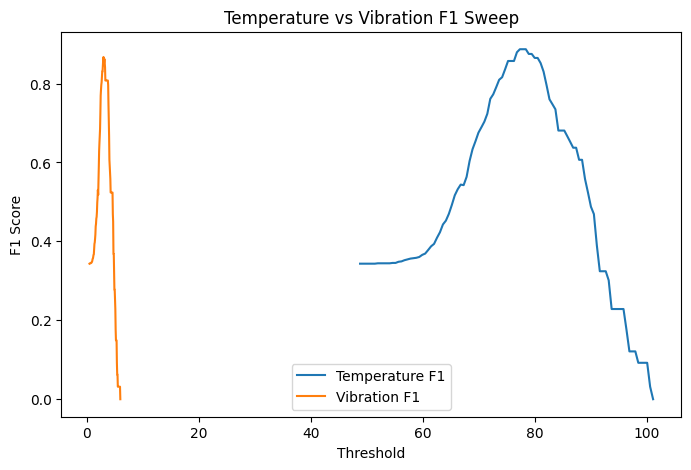

In [22]:
br = ai["vibration"].fillna(ai["vibration"].median())
bs = a.linspace(br.min(), br.max(), 100)
bt = []
for bg in bs:
    bh = (br.values > bg).astype(int)
    _, _, bk = bin_metrics(bc, bh)
    bt.append(bk)
bu, bv = c.subplots(figsize=(8, 5))
bv.plot(bb, bf, label="Temperature F1")
bv.plot(bs, bt, label="Vibration F1")
bv.set_xlabel("Threshold")
bv.set_ylabel("F1 Score")
bv.set_title("Temperature vs Vibration F1 Sweep")
bv.legend()
c.show()